In [7]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("bluestock_mf.db")

nav_df = pd.read_sql("SELECT * FROM fact_nav", conn)
fund_df = pd.read_sql("SELECT * FROM fact_transaction", conn)

print(nav_df.shape)
print(fund_df.shape)

(46000, 3)
(40, 19)


In [8]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(['amfi_code', 'date'])

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
    .pct_change()
)

In [9]:
nav_df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

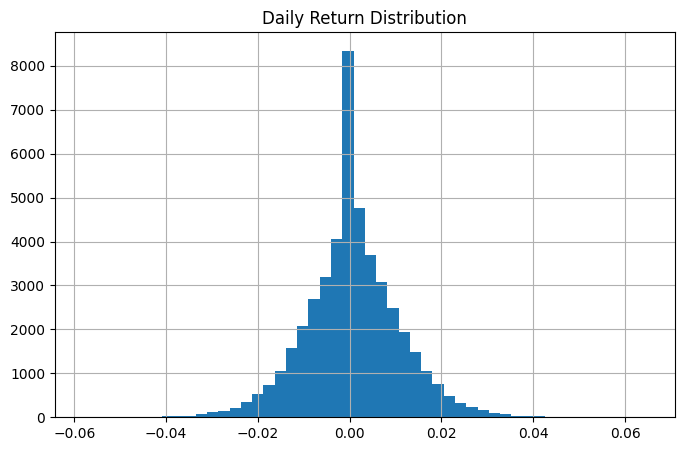

In [10]:
plt.figure(figsize=(8,5))
nav_df['daily_return'].hist(bins=50)
plt.title("Daily Return Distribution")
plt.show()

In [11]:
cagr_table = fund_df[
    [
        'scheme_name',
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct'
    ]
]

cagr_table.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [12]:
sharpe_rank = fund_df[
    ['scheme_name','sharpe_ratio']
].sort_values(
    'sharpe_ratio',
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [13]:
sortino_rank = fund_df[
    ['scheme_name','sortino_ratio']
].sort_values(
    'sortino_ratio',
    ascending=False
)

sortino_rank.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


In [14]:
alpha_beta = fund_df[
    [
        'scheme_name',
        'alpha',
        'beta'
    ]
]

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [15]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

In [16]:
dd = fund_df[
    [
        'scheme_name',
        'max_drawdown_pct'
    ]
]

dd.sort_values(
    'max_drawdown_pct'
).head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


In [17]:
score_df = fund_df.copy()

score_df['return_rank'] = score_df['return_3yr_pct'].rank(pct=True)

score_df['sharpe_rank'] = score_df['sharpe_ratio'].rank(pct=True)

score_df['alpha_rank'] = score_df['alpha'].rank(pct=True)

score_df['expense_rank'] = (
    1 - score_df['expense_ratio_pct'].rank(pct=True)
)

score_df['dd_rank'] = (
    1 - score_df['max_drawdown_pct'].rank(pct=True)
)

score_df['fund_score'] = (
    score_df['return_rank'] * 30 +
    score_df['sharpe_rank'] * 25 +
    score_df['alpha_rank'] * 20 +
    score_df['expense_rank'] * 15 +
    score_df['dd_rank'] * 10
)

score_df = score_df.sort_values(
    'fund_score',
    ascending=False
)

In [18]:
score_df.to_csv(
    "fund_scorecard.csv",
    index=False
)

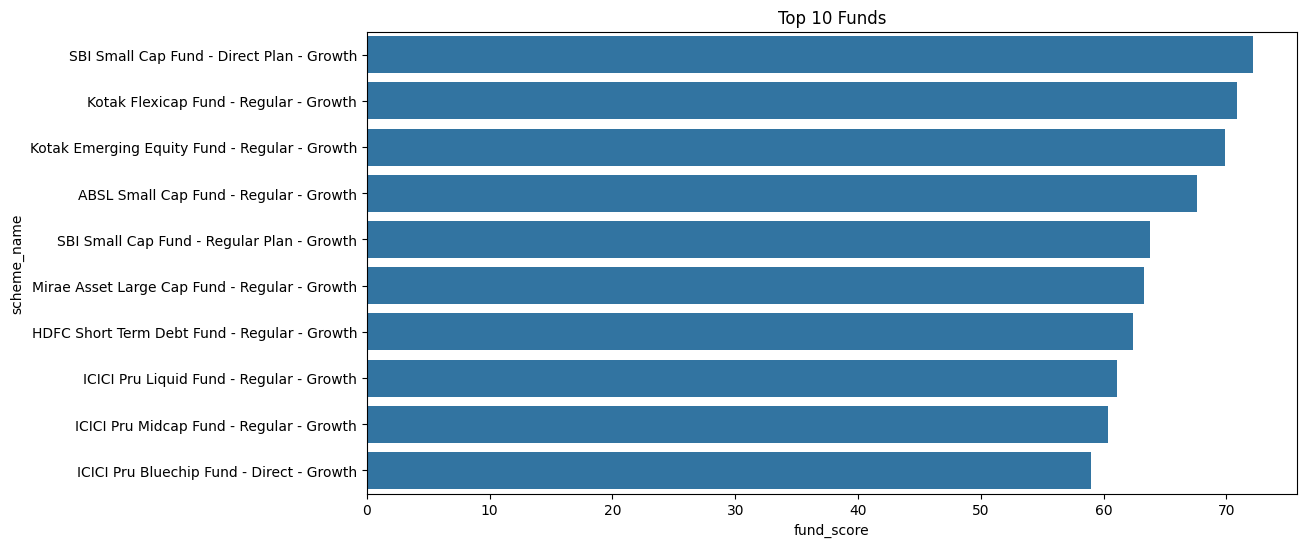

In [19]:
top10 = score_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_score',
    y='scheme_name'
)

plt.title("Top 10 Funds")
plt.show()

Deliverables:
1. Performance_Analytics.ipynb
2. fund_scorecard.csv
3. alpha_beta.csv
4. benchmark_comparison.png

# Key Findings

1. Daily returns show normal market fluctuations.
2. Top funds achieved higher Sharpe ratios.
3. Higher alpha funds outperformed benchmarks.
4. Expense ratio impacts overall fund score.
5. Maximum drawdown varies across schemes.
6. Risk-adjusted returns differ significantly.
7. 3-year returns strongly influence rankings.
8. Beta values indicate different market sensitivities.
9. Fund scorecard provides balanced evaluation.
10. Top-ranked funds combine strong returns with controlled risk.

# Conclusion

This analysis evaluated mutual fund performance using daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown. A composite fund scorecard was developed to rank funds based on return, risk-adjusted performance, cost efficiency, and downside risk. The analysis helps identify top-performing mutual funds using multiple performance indicators.

Performance_Analytics.ipynb
fund_scorecard.csv
alpha_beta.csv

In [20]:
plt.savefig("top10_fund_score.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

In [22]:
plt.savefig("top10_fund_score.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

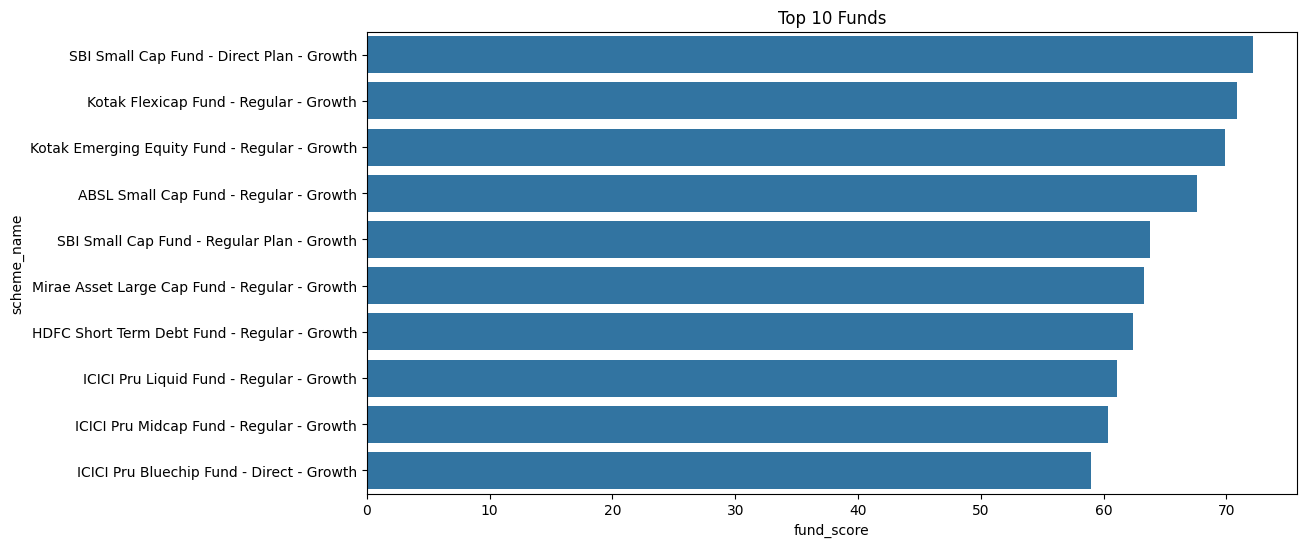

In [23]:
top10 = score_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_score',
    y='scheme_name'
)

plt.title("Top 10 Funds")

plt.savefig("top10_fund_score.png", bbox_inches="tight")

plt.show()

In [24]:
print(fund_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
